# 07 — Sampling, Aliasing, and Core Fourier Properties

## Learning goals

- Understand the Nyquist frequency and aliasing.
- Count how many Fourier components a sampled signal can represent.
- Verify addition, shift, Parseval, and convolution theorems numerically.

## Mental model

Sampling is a strobe light. If the strobe flashes too slowly, a fast wheel can look like it is spinning slowly or even backwards. That false slow motion is aliasing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Aliasing: a high frequency masquerades as a low frequency

If a signal is sampled at rate $R$, frequencies above $R/2$ cannot be represented uniquely. The boundary $R/2$ is the Nyquist frequency.

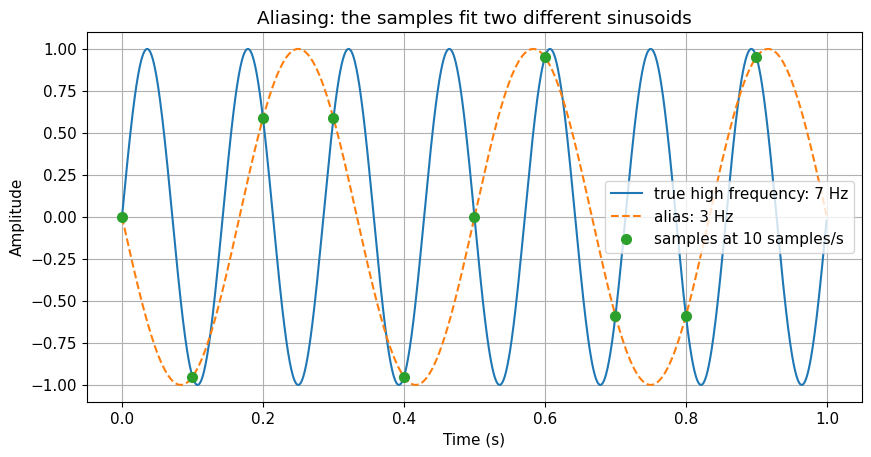

Sampling rate R = 10 samples/s
Nyquist frequency = R/2 = 5.0 Hz
The 7 Hz sinusoid aliases to 3 Hz in this setup.


In [2]:
R = 10                         # samples per second
f_high = 7                     # above Nyquist = 5 Hz
f_alias = abs(f_high - R)      # alias frequency for this example
T = 1.0

t_cont = np.linspace(0, T, 2000, endpoint=False)
t_samp = np.arange(0, T, 1/R)

x_high = np.sin(2*np.pi*f_high*t_cont)
x_alias = -np.sin(2*np.pi*f_alias*t_cont)
x_samples = np.sin(2*np.pi*f_high*t_samp)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(t_cont, x_high, label=f"true high frequency: {f_high} Hz")
ax.plot(t_cont, x_alias, "--", label=f"alias: {f_alias} Hz")
ax.plot(t_samp, x_samples, "o", markersize=7, label=f"samples at {R} samples/s")
ax.set_title("Aliasing: the samples fit two different sinusoids")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

print(f"Sampling rate R = {R} samples/s")
print(f"Nyquist frequency = R/2 = {R/2} Hz")
print(f"The {f_high} Hz sinusoid aliases to {f_alias} Hz in this setup.")

## How many Fourier components?

If $N$ real samples span $T$ seconds, then

$$\Delta f = \frac{1}{T}, \qquad f_{\mathrm{Nyq}} = \frac{N}{2T}.$$

So the number of positive-frequency sinusoidal components up to Nyquist is $N/2$.

In [3]:
N = 64
T = 2.0
R = N/T
fmin = 1/T
fnyq = R/2
print(f"N={N} samples across T={T} s")
print(f"R=N/T={R} samples/s")
print(f"Δf=1/T={fmin} Hz")
print(f"Nyquist=R/2={fnyq} Hz")
print(f"Nyquist / Δf = {fnyq/fmin} = N/2 components")

N=64 samples across T=2.0 s
R=N/T=32.0 samples/s
Δf=1/T=0.5 Hz
Nyquist=R/2=16.0 Hz
Nyquist / Δf = 32.0 = N/2 components


## Addition theorem

The Fourier transform of a sum is the sum of the Fourier transforms:

$$\mathcal{F}\{x_1+x_2\}=\mathcal{F}\{x_1\}+\mathcal{F}\{x_2\}.$$

In [4]:
R = 256
N = 256
t = np.arange(N)/R
x1 = np.cos(2*np.pi*8*t)
x2 = 0.7*np.sin(2*np.pi*30*t + 0.4)

lhs = np.fft.fft(x1 + x2)
rhs = np.fft.fft(x1) + np.fft.fft(x2)
print("Max difference for addition theorem:", np.max(np.abs(lhs-rhs)))

Max difference for addition theorem: 1.5618096471518126e-14


## Parseval's theorem: energy is conserved across domains

For NumPy's FFT convention,

$$\sum_n |x_n|^2 = \frac{1}{N}\sum_k |X_k|^2.$$

In [5]:
x = x1 + x2 + 0.2*np.random.default_rng(0).normal(size=N)
X = np.fft.fft(x)
energy_time = np.sum(np.abs(x)**2)
energy_freq = np.sum(np.abs(X)**2)/N
print("Energy in time domain:     ", energy_time)
print("Energy in frequency domain:", energy_freq)
print("Difference:", abs(energy_time-energy_freq))

Energy in time domain:      195.6300923066658
Energy in frequency domain: 195.6300923066658
Difference: 0.0


## Convolution theorem

Convolution in one domain becomes multiplication in the Fourier domain:

$$x*h \longleftrightarrow X\cdot H.$$

This is the idea behind fast filtering and deconvolution.

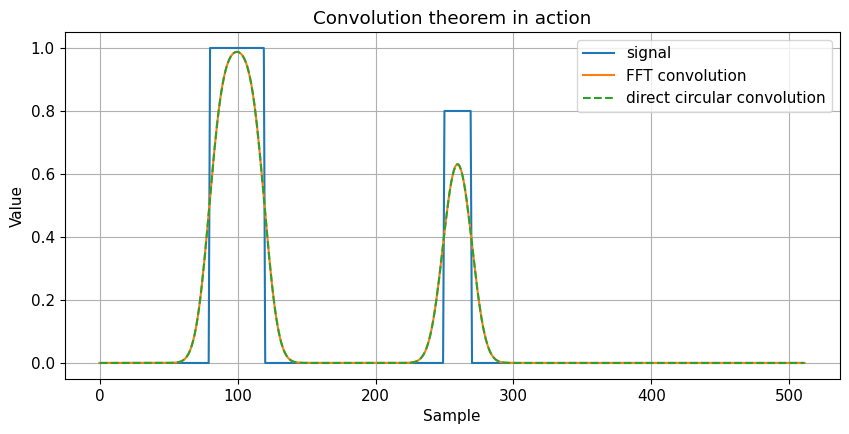

Max difference between FFT and direct convolution: 2.2204460492503136e-16


In [6]:
def gaussian_kernel(N, sigma):
    n = np.arange(N)
    center = 0
    # circular distance from zero
    d = np.minimum(n, N-n)
    h = np.exp(-(d**2)/(2*sigma**2))
    h /= h.sum()
    return h

N = 512
n = np.arange(N)
x = np.zeros(N)
x[80:120] = 1
x[250:270] = 0.8
h = gaussian_kernel(N, sigma=8)

# circular convolution directly by FFT multiplication
X = np.fft.fft(x)
H = np.fft.fft(h)
y_fft = np.fft.ifft(X*H).real

# direct circular convolution for checking
# y[n] = sum_m x[m] h[n-m]
y_direct = np.zeros(N)
for i in range(N):
    y_direct[i] = np.sum(x * np.roll(h, i))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(n, x, label="signal")
ax.plot(n, y_fft, label="FFT convolution")
ax.plot(n, y_direct, "--", label="direct circular convolution")
ax.set_title("Convolution theorem in action")
ax.set_xlabel("Sample")
ax.set_ylabel("Value")
ax.legend()
plt.show()

print("Max difference between FFT and direct convolution:", np.max(np.abs(y_fft-y_direct)))

## Shift theorem, in one line

Rolling a sampled signal shifts it. In the Fourier domain, that shift is a frequency-dependent phase factor.

In [7]:
shift = 25
x_shift = np.roll(x, shift)
X_shift = np.fft.fft(x_shift)
phase_factor = np.exp(-1j*2*np.pi*np.arange(N)*shift/N)
expected = X * phase_factor
print("Max shift-theorem difference:", np.max(np.abs(X_shift-expected)))

Max shift-theorem difference: 5.843167801182856e-13


## Checkpoint

1. Change the sample rate to 12 samples/s in the aliasing example. What alias do you see?
2. Increase `sigma` in the Gaussian kernel. What happens to the filtered signal?
3. Why does Parseval's theorem support the idea that a Fourier transform is a change of representation, not a loss of information?